In [8]:
bound = 20
ABs = flatten([[(A,B) for B in srange(-bound,bound) if 4*A^3+27*B^2!= 0] for A in srange(-bound,bound)], max_level=1)
ABs.sort(key=lambda x : x[0]^2+x[1]^2)
ABs[:10]


[(-1, 0),
 (0, -1),
 (0, 1),
 (1, 0),
 (-1, -1),
 (-1, 1),
 (1, -1),
 (1, 1),
 (-2, 0),
 (0, -2)]

In [9]:
li2 = []
li0 = []
for A,B in ABs:
    E = EllipticCurve([A,B])
    try:
        r = E.rank(use_database=True)
    except:
        pass
    else:
        if r>1:
            X = E.integral_points()
            print(f"{A}, {B}, rank={r} has {len(X)} integral points: {X}")
            li2.append((A,B))
        if r==0 and A^2+B^2<100:
            if E.torsion_order() > 2:
                print(f"{A}, {B} has {E.torsion_order()} torsion points {E.torsion_points()}")
                li0.append((A,B))

-1, 0 has 4 torsion points [(0 : 1 : 0), (-1 : 0 : 1), (0 : 0 : 1), (1 : 0 : 1)]
0, 1 has 6 torsion points [(0 : 1 : 0), (-1 : 0 : 1), (0 : -1 : 1), (0 : 1 : 1), (2 : -3 : 1), (2 : 3 : 1)]
-2, 1 has 4 torsion points [(0 : 1 : 0), (0 : -1 : 1), (0 : 1 : 1), (1 : 0 : 1)]
1, 2 has 4 torsion points [(0 : 1 : 0), (-1 : 0 : 1), (1 : -2 : 1), (1 : 2 : 1)]
-4, 0 has 4 torsion points [(0 : 1 : 0), (-2 : 0 : 1), (0 : 0 : 1), (2 : 0 : 1)]
0, 4 has 3 torsion points [(0 : 1 : 0), (0 : -2 : 1), (0 : 2 : 1)]
4, 0 has 4 torsion points [(0 : 1 : 0), (0 : 0 : 1), (2 : -4 : 1), (2 : 4 : 1)]
-4, 1, rank=2 has 11 integral points: [(-2 : -1 : 1), (-1 : -2 : 1), (0 : -1 : 1), (2 : -1 : 1), (3 : -4 : 1), (4 : -7 : 1), (10 : -31 : 1), (12 : -41 : 1), (20 : -89 : 1), (114 : -1217 : 1), (1274 : -45473 : 1)]
-1, 4, rank=2 has 7 integral points: [(-1 : -2 : 1), (0 : -2 : 1), (1 : -2 : 1), (4 : -8 : 1), (15 : -58 : 1), (17 : -70 : 1), (4064 : -259078 : 1)]
4, -1, rank=2 has 3 integral points: [(1 : -2 : 1), (5 : -1

In [10]:
len(li0), len(li2)

(11, 206)

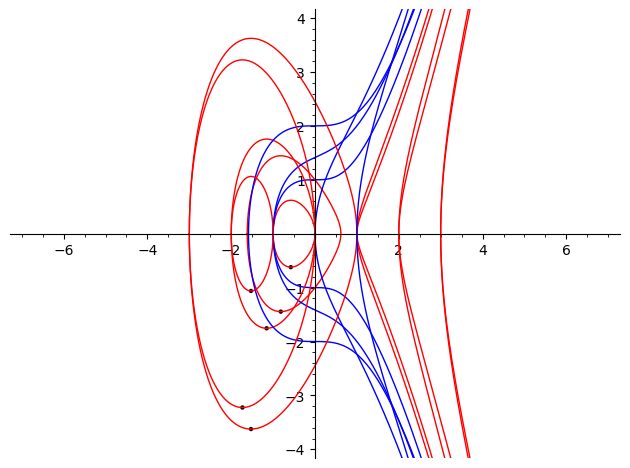

In [17]:
gr = Graphics()
for (A,B) in li0:
    co = "red" if A<0 else "blue"
    if A<0:
        x0 = sqrt(-A/3)
        ysq = x0^3+A*x0+B
        if ysq > 0:
            gr += point([x0,sqrt(ysq)],color="black")
        ysq = -x0^3-A*x0+B
        if ysq > 0:
            gr += point([-x0,-sqrt(ysq)], color="black")
    gr += plot(EllipticCurve([A,B]), xmin=-7, xmax=7, ymax=4, ymin=-4, color=co)
gr.show(xmin=-7, xmax=7, ymin=-4, ymax=4)
    

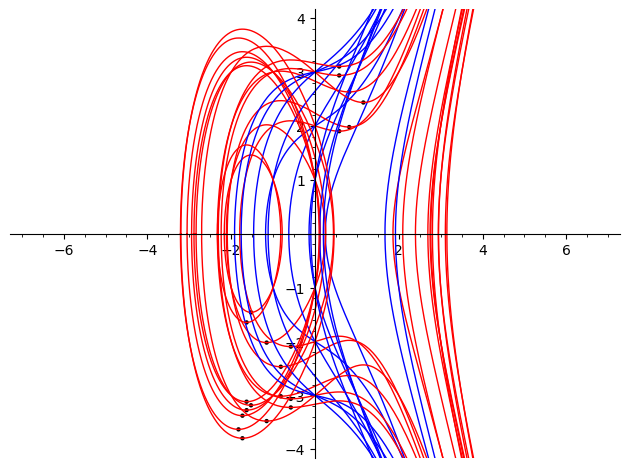

In [18]:
gr = Graphics()
for (A,B) in li2[:30]:
    co = "red" if A<0 else "blue"
    if A<0:
        x0 = sqrt(-A/3)
        ysq = x0^3+A*x0+B
        if ysq > 0:
            gr += point([x0,sqrt(ysq)],color="black")
        ysq = -x0^3-A*x0+B
        if ysq > 0:
            gr += point([-x0,-sqrt(ysq)], color="black")
    gr += plot(EllipticCurve([A,B]), xmin=-7, xmax=7, ymax=4, ymin=-4, color=co)
gr.show(xmin=-7, xmax=7, ymin=-4, ymax=4)

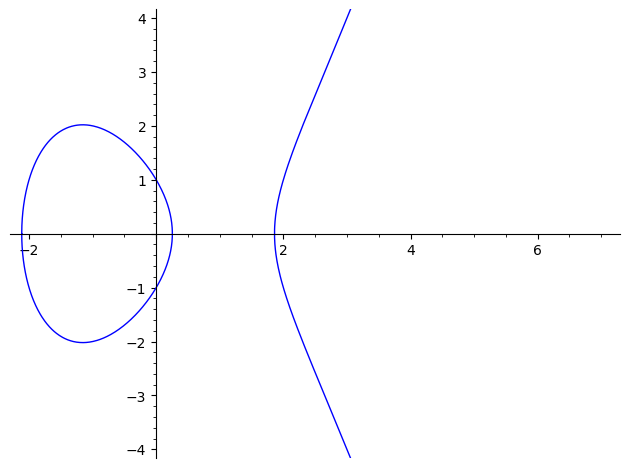

In [19]:
E = EllipticCurve([-4,1])
E.plot(ymin=-4, ymax=4, xmin=-7.11, xmax=7.11)

In [24]:
P,Q = E.gens()
P,Q, P.height(), Q.height()

((-1 : 2 : 1), (0 : 1 : 1), 0.945023010045590, 0.272741202034130)

In [25]:
E.height_pairing_matrix()

[ 0.945023010045590 -0.348250646165293]
[-0.348250646165293  0.272741202034130]

In [23]:
E.torsion_points()

[(0 : 1 : 0)]

In [29]:
pts_in_pic = []
for n in srange(-50, 50):
    for m in srange(-50,50):
        R = n*P+m*Q
        if R != 0:
            if R[0].abs() < 7.11 and R[1].abs() < 4:
                pts_in_pic.append((R, n, m))
pts_in_pic.sort(key=lambda R : R[0].height())
pts_in_pic[:50]

[((0 : -1 : 1), 0, -1),
 ((0 : 1 : 1), 0, 1),
 ((-7/4 : -13/8 : 1), 0, -3),
 ((-7/4 : 13/8 : 1), 0, 3),
 ((92/49 : 113/343 : 1), 0, -4),
 ((92/49 : -113/343 : 1), 0, 4),
 ((-90/49 : -503/343 : 1), -1, -4),
 ((-90/49 : 503/343 : 1), 1, 4),
 ((154/81 : 377/729 : 1), -1, -5),
 ((154/81 : -377/729 : 1), 1, 5),
 ((-10/169 : -2443/2197 : 1), -1, -2),
 ((-10/169 : 2443/2197 : 1), 1, 2),
 ((-153/121 : 2674/1331 : 1), -1, -6),
 ((-153/121 : -2674/1331 : 1), 1, 6),
 ((-728/529 : 24023/12167 : 1), 0, -5),
 ((-728/529 : -24023/12167 : 1), 0, 5),
 ((127/2401 : 104474/117649 : 1), -1, 0),
 ((127/2401 : -104474/117649 : 1), 1, 0),
 ((1598/8281 : 365539/753571 : 1), -1, -8),
 ((1598/8281 : -365539/753571 : 1), 1, 8),
 ((82264/505521 : 213664697/359425431 : 1), 0, -7),
 ((82264/505521 : -213664697/359425431 : 1), 0, 7),
 ((-879602/531441 : 680624119/387420489 : 1), -1, 2),
 ((-879602/531441 : -680624119/387420489 : 1), 1, -2),
 ((-672194/2053489 : -4437740041/2942649737 : 1), -1, -10),
 ((-672194/20534

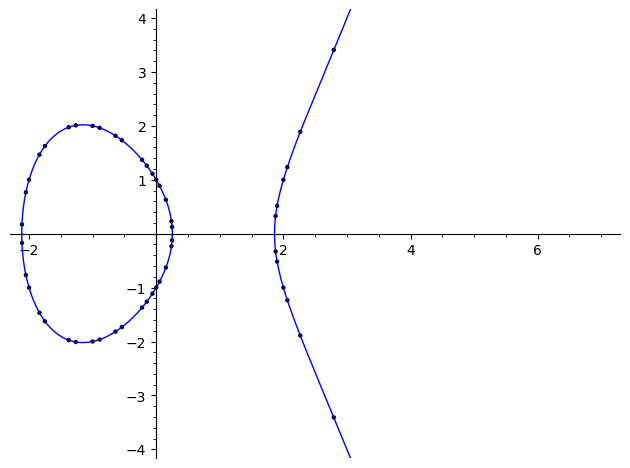

In [28]:
gr = E.plot(ymin=-4, ymax=4, xmin=-7.11, xmax=7.11)
for P in pts_in_pic[0:50]:
    gr += point([P[0],P[1]],color="black")
gr.show()